# **Install and Import Package**


In [6]:
#Install required libraries (run only 1 time)
%pip install requests
%pip install matplotlib



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import requests
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt


import nltk
import re
from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.sentiment.vader import  SentimentIntensityAnalyzer

#Initialise VADER sentiment analysis
sia = SentimentIntensityAnalyzer()


# **Step 1: Crawl a Real-World Dataset**

In [8]:
#Step1: Ste up Reddit scraping parameters
subreddit = 'apple'
timeframe = 'year'   # hour, day, week, month, year, all
listing = 'top' # controversial, best, hot, new, random, rising, top
limit = 250    #posts per page 

In [ ]:
def get_reddit(subreddit, listing, limit, timeframe):
    """
    Pull the first page of pots from subreddit using Reddit's public API.

    Parameters: 
        subreddit (str): Name of the subreddit 
        listing (str): Sorting post type 
        limit (int): Maximum number of posts to request
        timeframe (str): Time range for post 

    Returns: 
        Response object
    """
    try:
        base_url = (
            f'https://www.reddit.com/r/{subreddit}/{listing}.json'
            f'?limit={limit}&t={timeframe}'
        )
        request = requests.get(base_url, headers={'User-agent': 'SDPA'})
    except Exception as e:
        print('An Error Occurred in get_reddit:', e)
        return None
    return request


def get_reddit_after(subreddit, listing, limit, timeframe, after_token):
    """
    Get Reddit posts after a specific token (pagination)
    
    The 'after' token tells reddit where the previous page ended, 
    so we can request the next batch posts.

    Parameters: 
        subreddit (str): Subreddit name
        listing (str): Sorting type
        limit (int): Number of posts to request
        timeframe (str): Time range for listing post
        after_token (str): Token representing where to continue next post

    Returns: 
        Response object (or None if an error occurs)
    """
    try:
        base_url = (
            f'https://www.reddit.com/r/{subreddit}/{listing}.json'
            f'?limit={limit}&t={timeframe}&after={after_token}'
        )
        request = requests.get(base_url, headers={'User-agent': 'SDPA'})
    except Exception as e:
        print('An Error Occurred in get_reddit_after:', e)
        return None
    return request

In [ ]:
# Page 1 
r = get_reddit(subreddit, listing, limit, timeframe)
data = json.loads(r.content)

temp = []
children = data['data']['children']
print('Page 1 posts:', len(children))

for i in range(len(children)):
    post = children[i]['data']
    temp.append([
        post['title'],
        post['ups'],
        post['link_flair_text'],
        post['num_comments'],
        post['selftext'],
        post['created_utc'],
        post['id']
    ])

top100 = pd.DataFrame(
    np.array(temp, dtype=object),
    columns=['Title', 'Upvotes', 'Flair', 'Num_Comments',
             'Body', 'Created_UTC', 'Post_ID']
)

# Page 2  
after_token = data['data']['children'][len(children)-1]['kind'] + '_' + \
              data['data']['children'][len(children)-1]['data']['id']

r_new = get_reddit_after(subreddit, listing, limit, timeframe, after_token)
data_second = json.loads(r_new.content)

temp = []
children2 = data_second['data']['children']
print('Page 2 posts:', len(children2))

# Only take up to 100 posts from Page 2 to avoid reject from API 
for i in range(min(100, len(children2))):
    post = children2[i]['data']
    temp.append([
        post['title'],
        post['ups'],
        post['link_flair_text'],
        post['num_comments'],
        post['selftext'],
        post['created_utc'],
        post['id']
    ])

top200 = pd.DataFrame(
    np.array(temp, dtype=object),
    columns=['Title', 'Upvotes', 'Flair', 'Num_Comments',
             'Body', 'Created_UTC', 'Post_ID']
)

#  Page 3 (Only 50 posts can be pulled)
after_token_second = children2[len(children2)-1]['kind'] + '_' + \
                     children2[len(children2)-1]['data']['id']

r_new2 = get_reddit_after(subreddit, listing, limit, timeframe, after_token_second)
data_third = json.loads(r_new2.content)

temp = []
children3 = data_third['data']['children']
print('Page 3 posts:', len(children3))

for i in range(len(children3)):
    post = children3[i]['data']
    temp.append([
        post['title'],
        post['ups'],
        post['link_flair_text'],
        post['num_comments'],
        post['selftext'],
        post['created_utc'],
        post['id']
    ])

top250 = pd.DataFrame(
    np.array(temp, dtype=object),
    columns=['Title', 'Upvotes', 'Flair', 'Num_Comments',
             'Body', 'Created_UTC', 'Post_ID']
)

# Combine all into one dataset 
top_reddit_posts = pd.concat([top100, top200, top250], ignore_index=True)

# Ensure numeric columns are of correct type
top_reddit_posts['Upvotes'] = pd.to_numeric(top_reddit_posts['Upvotes'])
top_reddit_posts['Num_Comments'] = pd.to_numeric(top_reddit_posts['Num_Comments'])

print('Final combined shape:', top_reddit_posts.shape)

#Save to CSV 
top_reddit_posts.to_csv('reddit_top_posts_year.csv', index=False)
top_reddit_posts

Page 1 posts: 100
Page 2 posts: 100
Page 3 posts: 50
Final combined shape: (250, 7)


,Title,Upvotes,Flair,Num_Comments,Body,Created_UTC,Post_ID
0,"iPhones Could Cost Up to $2,300 in the U.S. Du...",13574,iPhone,1362,,1743785410.0,1jrgmvl
1,Most iPhone owners see little to no value in A...,11265,Apple Intelligence,1431,,1734363217.0,1hflpje
2,Apple shareholders say no to scrapping company...,9869,Discussion,701,,1740503162.0,1ixzyrj
3,Apple sued for false advertising over Apple In...,8765,Apple Intelligence,610,,1742509626.0,1jg1k6j
4,Apple is racing to fly planes of iPhones into ...,7780,iPhone,550,,1744054856.0,1jtu9k4
...,...,...,...,...,...,...,...
245,iPhone 17 Air Launching Later This Year With T...,1469,iPhone,461,,1745508497.0,1k6v2ir
246,Apple considers expanding iPhone assembly in B...,1471,iPhone,567,,1743851599.0,1js144l
247,Introducing iPhone Pocket: a beautiful way to ...,1466,iPhone,1407,,1762852511.0,1ou4vur
248,Ted Lasso season 4 starts filming in July,1462,Apple TV+,186,,1748112176.0,1kuipqd


### 1. Data Collection

In this project, I collected data from public Reddit API using the 'requests' library in Python. The target dataset consists of the **top posts from r/apple community over the past year**, based on Reddit's own "top" listing.

**Data Source**

- Platform: Reddit
- Subreddit: 'r/apple'
- Endpoint: 'https://www.reddit.com/r/{subreddit}/{listing}.json'
- Access method: Public API (no authentication token, using USER-Agent)

**Scraping Strategy**

Reddit's API only returns a limited number of posts per request. To collect as much as possible, I used **pagination with thie 'after' token**:

1. Request Page 1 using '/top.json' with 't=year' and 'limit=250'.
2. Extract the last pot's 'kind' and 'id' to build an 'after' token.
3. Use the token to request **Page 2** (posts after the precious batch).
4. Repeat the process for **Page 3** to reach around 250 posts in total.
5. Combine all pages into single table dataframe.

**Variable collected**

For each Reddit post, I extracted:
- 'Title' : Post title text
- 'Upvotes' : Number of upvotes or like ('ups')
- 'Flair' : Post flair label (topic/category)
- 'Num_Comments': Number of comments
- 'Body' : Post self-text (for text posts)
- 'Created_UTC' : Post creation time in Unix timestamp
- 'Post_ID' : Unique Reddit post ID

These were stored in three intermediate Dataframes (top100', 'top200', 'top250'), which were then combine into a final dataset called 'top_reddit_posts'

The final dataset is also exported to CSV file types for later analysis: 'reddit_top_posts_year.csv'


# **Step 2: Perform data preparation and cleaning**

## 2.1 Add features column and Enrich Data

### 2.1.1 Convert Unix Timestamp to Real Date

Reddit has provided the post creation time in UNIX timestamp format, which is the number of seconds since 1 January 1970. 
To analyze trends over time (daily posting patterns, upvotes over time, etc.) we must convert this into human-readable datetime format.

In [12]:
#Convert UNIX Timestamp into Real Date
top_reddit_posts['Created_At'] = pd.to_datetime(top_reddit_posts['Created_UTC'], unit='s')

After converting to datetime, we extract:
- Date only: for grouping by day/month
- Time only: for identify post patterns (peak hours)

In [ ]:
# Convert full timestamp into date column

# Extract calendar date (YYYY-MM-DD)
top_reddit_posts['Created_Date'] = top_reddit_posts['Created_At'].dt.date #Extract calendar date

#Extract the time of day (HH:MM:SS)
top_reddit_posts['Created_Time'] = top_reddit_posts['Created_At'].dt.time #Extract Time 

In [14]:
top_reddit_posts

,Title,Upvotes,Flair,Num_Comments,Body,Created_UTC,Post_ID,Created_At,Created_Date,Created_Time
0,"iPhones Could Cost Up to $2,300 in the U.S. Du...",13574,iPhone,1362,,1743785410.0,1jrgmvl,2025-04-04 16:50:10,2025-04-04,16:50:10
1,Most iPhone owners see little to no value in A...,11265,Apple Intelligence,1431,,1734363217.0,1hflpje,2024-12-16 15:33:37,2024-12-16,15:33:37
2,Apple shareholders say no to scrapping company...,9869,Discussion,701,,1740503162.0,1ixzyrj,2025-02-25 17:06:02,2025-02-25,17:06:02
3,Apple sued for false advertising over Apple In...,8765,Apple Intelligence,610,,1742509626.0,1jg1k6j,2025-03-20 22:27:06,2025-03-20,22:27:06
4,Apple is racing to fly planes of iPhones into ...,7780,iPhone,550,,1744054856.0,1jtu9k4,2025-04-07 19:40:56,2025-04-07,19:40:56
...,...,...,...,...,...,...,...,...,...,...
245,iPhone 17 Air Launching Later This Year With T...,1469,iPhone,461,,1745508497.0,1k6v2ir,2025-04-24 15:28:17,2025-04-24,15:28:17
246,Apple considers expanding iPhone assembly in B...,1471,iPhone,567,,1743851599.0,1js144l,2025-04-05 11:13:19,2025-04-05,11:13:19
247,Introducing iPhone Pocket: a beautiful way to ...,1466,iPhone,1407,,1762852511.0,1ou4vur,2025-11-11 09:15:11,2025-11-11,09:15:11
248,Ted Lasso season 4 starts filming in July,1462,Apple TV+,186,,1748112176.0,1kuipqd,2025-05-24 18:42:56,2025-05-24,18:42:56


### 2.1.2 Add Setimental Analysis Features

This section we
1. Remove old sentiment columns to avoid bug (duplication) when the code is rerun 
2. Apply VADER to compute: 
   1. Title_compound --> continuous sentiment score
   2. Title_Sent --> categorical Positive/Neutral/Negative

These will be used for: 
- sentiment distribution analysis
- correlation
- hypothesis test

In [ ]:
 # Remove ALL old VADER columns if they exist (In case rerun the code)
cols_to_remove = [
    'Title_compound', 'Title_Sent',
    'title_neg', 'title_neu', 'title_pos', 
    'title_compound'
]

top_reddit_posts.drop(
    columns=[c for c in cols_to_remove if c in top_reddit_posts.columns],
    inplace=True
)

# calculate new sentiment by apply VADER sentiment analysis on post titles
results = []

for headline in top_reddit_posts['Title']:
    sentiment = sia.polarity_scores(headline)
    compound = sentiment['compound']

    if compound >= 0.05:
        sentiment_class = 'Positive'
    elif compound <= -0.05:
        sentiment_class = 'Negative'
    else:
        sentiment_class = 'Neutral'
    
    results.append({
        'Title_compound': compound,
        'Title_Sent': sentiment_class
    })

#Convert to Dataframe and attach to main table
sentimental_title = pd.DataFrame(results)
top_reddit_posts = pd.concat([top_reddit_posts, sentimental_title], axis=1)

# Ensure compound is numeric
top_reddit_posts['Title_compound'] = pd.to_numeric(top_reddit_posts['Title_compound'])


sentimental_title

,Title_compound,Title_Sent
0,0.0000,Neutral
1,0.5130,Positive
2,-0.2960,Negative
3,0.4767,Positive
4,0.0000,Neutral
...,...,...
245,0.0000,Neutral
246,0.0000,Neutral
247,0.5994,Positive
248,0.0000,Neutral


### 2.1.3 Add Word Count Features

This section to understand text patterns and their relationships with engagement, we compute: 
- Title Word Count
- Body Word Count

These are important for:
- Checking if longer posts receive more engagement 
- Understanding writing style differences between flairs
- Use regression/ modeling later

In [16]:
# Title Word Count
top_reddit_posts['Title_Word_Count'] = top_reddit_posts['Title'].astype(str).str.split().str.len()

# Body Word Count
top_reddit_posts['Body_Word_Count'] = top_reddit_posts['Body'].astype(str).str.split().str.len()

## 2.2 Handle Data

### 2.2.1 Handle Missing Data

Handle missing data by replace:
- Missing Flair: "None"
- Missing Body: Empty string

This avoids errors in analysis and prevents NaNs from contaminating plots or calcualtions

In [ ]:
top_reddit_posts['Flair'] = top_reddit_posts['Flair'].fillna('None')
top_reddit_posts['Body'] = top_reddit_posts['Body'].fillna('')
top_reddit_posts


### 2.2.2 Identify & Handle Outliers

#### 2.2.2.1 Check for Skewness

**Check for Skewness** which tell us if a feature is:
- Symmetric
- Moderately skewed
- Highly skewed

This helps decide if we need outlier handling or not

We check skewness for: 
- Upvotes
- Num_Comments
- Title_compound
- Title_Word_Count
- Body_Word_Count

In [69]:
cols = ['Upvotes', 'Num_Comments', 'Title_compound', 'Title_Word_Count', 'Body_Word_Count']

for col in cols:
    skew_value = top_reddit_posts[col].skew()

    # Interpretation rule
    if abs(skew_value) > 1:
        interpretation = 'Highly skewed'
    elif abs(skew_value) > 0.5:
        interpretation = 'Moderately skewed'
    else:
        interpretation = 'Approximately symmetric'
    
    print(f'{col}: {skew_value:.4f} --> {interpretation}')

Upvotes: 3.3624 --> Highly skewed
Num_Comments: 2.5861 --> Highly skewed
Title_compound: -0.1212 --> Approximately symmetric
Title_Word_Count: 3.0856 --> Highly skewed
Body_Word_Count: 7.5258 --> Highly skewed


**Distribution Characteristics of the Dataset**

After calculating skewness of numeric variables, we can observed that **most engagement-related and length-related features are highly skewed**

- **Upvotes (Skew = 3.3624)**
  This indicates long right tail, this shows that a few posts receive extremely high upvotes, while most receive relatively low numbers, which is normal for social media platforms where only handful of posts can go viral. 

- **Number of Comments (Skew = 2.5861)**
  A small number of posts attract disproportionate attention, leading to heavily skewed distribution. 

- **Title Sentiment Compound Score (Skew = -0.1212)**
  This value is close to zero which show that it roughly symmetric.

- **Title Word Count (Skew = 3.0856)**
  This shows that most titles are short, leading to shrong right skew.

- **Body Word Count (Skew = 7.5258)**
  This value show an extremely skewed because many posts have no body text, while few contain long paragraphs.

Therefore, **engagement and text-length variables are dominated by a few extreme posts**, while most items remain low. 

#### 2.2.2.2 Log transformation 
**Use Log-Transform on the highly skewed features**

Highly skewed data may distort regression and hypothesis tests. 

To reduce skewness, we apply log1p() to:
- Upvotes
- Num_Comments
- Body_Word_Count

(Title_compound does not need log)

In [19]:
top_reddit_posts['Log_Upvotes'] = np.log1p(top_reddit_posts['Upvotes'])
top_reddit_posts['Log_Num_Comments'] = np.log1p(top_reddit_posts['Num_Comments'])
top_reddit_posts['Log_Body_Word_Count'] = np.log1p(top_reddit_posts['Body_Word_Count'])

#### 2.2.2.3 Rechecking Skewness after transformation

In [20]:
cols = ['Log_Upvotes', 'Log_Num_Comments', 'Title_compound', 'Title_Word_Count', 'Log_Body_Word_Count']

for col in cols:
    skew_value = top_reddit_posts[col].skew()

    # Interpretation rule
    if abs(skew_value) > 1:
        interpretation = 'Highly skewed'
    elif abs(skew_value) > 0.5:
        interpretation = 'Moderately skewed'
    else:
        interpretation = 'Approximately symmetric'
    
    print(f'{col}: {skew_value:.4f} --> {interpretation}')

Log_Upvotes: 1.5107 --> Highly skewed
Log_Num_Comments: -1.9282 --> Highly skewed
Title_compound: -0.1212 --> Approximately symmetric
Title_Word_Count: 3.0856 --> Highly skewed
Log_Body_Word_Count: 3.1478 --> Highly skewed


Log transformation was used to reduce the impact of extreme values in Upvotes, Comments and Word Counts. After applying, you can see the skewness level decreased. Overall , its improve:
1. normality of data
2. stability for correlation and regression analysis 
3. reduced influence of outliers

However, data may not be symmetric as it is a social media platform that can make the outliers can appear. The transformed variables are now more suitable for testing and modeling.

# **Step 3: Perform exploratory analysis** 

In this section, I explore the Reddit dataset to understand the ditribution of numerical variables, posting behaviour across flair categories, common word patterns, and sentiment patterns. 

## 3.1 Statistic Descriptive

The table provides descriptive statistics (mean, min, max, quartiles, standard deviation) for the main numerical variables such as Upvotes, Number of Comments, sentiment compound score, and word counts. 

In [22]:
numeric_cols = ['Upvotes','Num_Comments', 'Title_compound', 'Title_Word_Count', 'Body_Word_Count']
top_reddit_posts[numeric_cols].describe()

,Upvotes,Num_Comments,Title_compound,Title_Word_Count,Body_Word_Count
count,250.000000,250.000000,250.000000,250.000000,250.000000
mean,2577.152000,475.140000,0.031278,12.172000,7.924000
std,1591.092139,352.368544,0.296939,5.656714,40.363089
min,1462.000000,0.000000,-0.790600,2.000000,0.000000
25%,1663.250000,249.250000,0.000000,9.000000,0.000000
50%,2071.000000,371.000000,0.000000,11.000000,0.000000
75%,2763.750000,599.000000,0.165425,13.000000,0.000000
max,13574.000000,2927.000000,0.784500,50.000000,413.000000


The numerical summary statistics provide an initial understanding of the distribution and scale of the key variables in the dataset. *Upvotes* range widely from **1,462 to 13,574** showing variation in how much engagment Reddit posts receive. The mean of upvote is much higher than median **(2,577 > 2,071)** which indicate right skewed distribution, where a small number of highly upvoted posts pull average upward. A similar pattern also appears in *Num_Comments*, with values from **0 to 2,927** and also mean of 475 which also show only few highly discussed posts.

The *Sentiment Compound* for title also scores range from **-0.79 to 0.78** which is interesting as it cover full negative to positive sentiment spectrum. However, both mean **(0.03)** and median **(0.00)** show that most titles tend to be neutral.

*Title_Word_Count* averages is around **12 words**, with most titles being short and concise, and also max of **50 words**. On the other hand, *Body_Word_Count* shows extremely high variability. The median is **0**, meaning that more than half of the posts contain **no body text**, while few long posts can reach up to **413 words**, which show highly skewed distribution. 

##  **3.2 Flair Analysis**

### **3.2.1 Flair Distribution Pie Chart**

This table shows how many posts belong to each flair label as originally scraped.

In [23]:
top_reddit_posts.groupby('Flair').count()   

,Title,Upvotes,Num_Comments,Body,Created_UTC,Post_ID,Created_At,Created_Date,Created_Time,Title_compound,Title_Sent,Title_Word_Count,Body_Word_Count,Log_Upvotes,Log_Num_Comments,Log_Body_Word_Count
Flair,,,,,,,,,,,,,,,,
AirPods,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12
App Store,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5
Apple Card,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
Apple Intelligence,22,22,22,22,22,22,22,22,22,22,22,22,22,22,22,22
Apple Music,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
Apple News+,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
Apple Newsroom,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5
Apple Pay,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
Apple Retail,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1


Many flair labels are inconsisten (space dif, uncommon categories) 
This step cleans the flair values, group rare categories as "Other" and creates Pie Chart to show distribution of **Apple** subreddit topics.

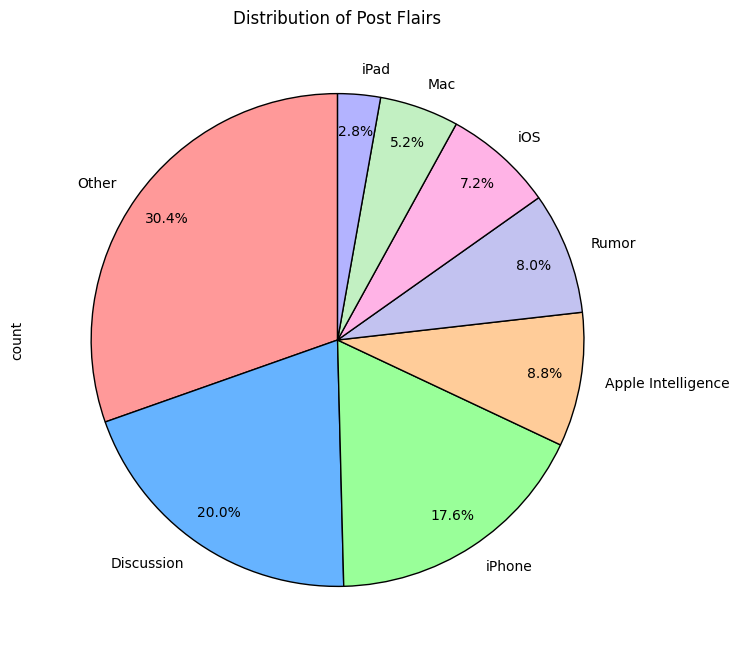

In [24]:
exclude_flair_none = top_reddit_posts[top_reddit_posts['Flair'] != 'None'].copy()

# Normalise text: remove spaces and standardise case (As some of flair have spacebar)
exclude_flair_none['Flair'] = exclude_flair_none['Flair'].str.strip()

main_flairs = [
    'iPhone',
    'Discussion',
    'iOS',
    'Mac',
    'Rumor',
    'iPad',
    'Apple Intelligence'
]

# Clean flairs
top_reddit_posts['Flair_Clean'] = exclude_flair_none['Flair'].copy()
top_reddit_posts['Flair_Clean'] = top_reddit_posts['Flair_Clean'].where(top_reddit_posts['Flair_Clean'].isin(main_flairs), other='Other')
top_reddit_posts = top_reddit_posts.copy()

# Count categories
count_flair = top_reddit_posts['Flair_Clean'].value_counts()

# Custom color palette (8 colors) 
colors = [
    '#ff9999', '#66b3ff', '#99ff99', '#ffcc99',
    '#c2c2f0', '#ffb3e6', '#c2f0c2', '#b3b3ff',
]

# Plot 
plt.figure(figsize=(11,8))
count_flair.plot(
    kind='pie',
    colors=colors[:len(count_flair)],  # Use only the number of categories
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.85,
    wedgeprops={'edgecolor':'black'}
)

plt.title('Distribution of Post Flairs')
plt.show()

The pie chart shows which topic has been talkign about in the **Apple** subreddit. 

The largest porition of posts (30.4%) falls under the **"Other"** category which shows a wide range of miscellaneous topic that do not fit with predefined flair. Next are **Discussion (20.0%)** and **iPhone(17.6%)** which suggest that people in comunity often engage in general conversations or share information and news related to iPhone. Thirdly, **Apple Intelligence (8.8%)** have been show as notable categories as it had been introduced on **10 June 2024** at Worldwide Developers Conference (WWDC) which have show active interest of users in related topic about new software updates and news. **Rumor (8.0%)** and **iOS (7.2%)** also notable as it also show that people interest in speculative news and software updates for Apple products. However, **Mac (5.2%)** and **iPad (2.8%)** appears less in the top posts. 

### **3.2.2 Upvotes by Flair**

To understnad which topics receive the highest engagement, we also compute the average number of upvotes for each flair category. 

This bar chart shows which topics the community finds more interesting according to Upvotes

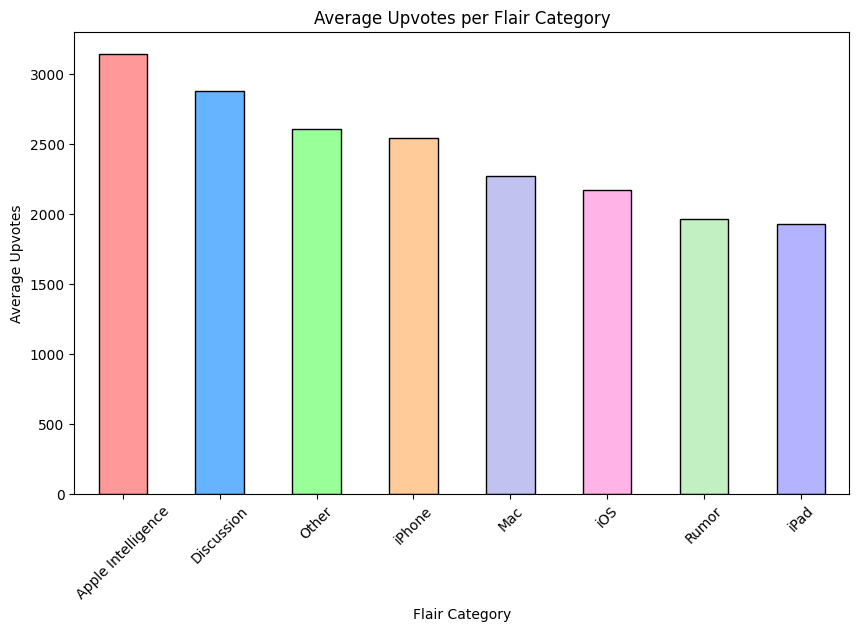

In [25]:
# Upvotes by Flair
Upvotes_By_Flair = top_reddit_posts.groupby('Flair_Clean')['Upvotes'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
colors = [
	'#ff9999',
    '#66b3ff', 
    '#99ff99', 
    '#ffcc99',
	'#c2c2f0', 
    '#ffb3e6', 
    '#c2f0c2', 
    '#b3b3ff',
]
Upvotes_By_Flair.plot(kind='bar', color=colors, edgecolor='black')

plt.title('Average Upvotes per Flair Category')
plt.xlabel('Flair Category')
plt.ylabel('Average Upvotes')
plt.xticks(rotation=45)
plt.show()

### 3.2.3 Number of Comments by Flair

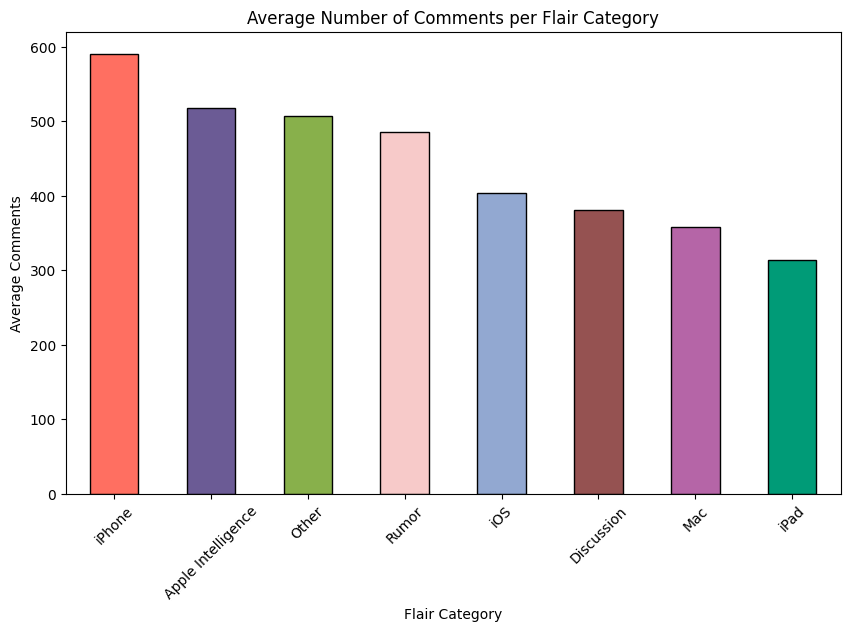

In [26]:
comments_by_flair = top_reddit_posts.groupby('Flair_Clean')['Num_Comments'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
colors = [
    '#FF6F61',  
    '#6B5B95',  
    '#88B04B',  
    '#F7CAC9',  
    '#92A8D1',  
    '#955251',  
    '#B565A7',  
    '#009B77'   
]
comments_by_flair.plot(kind='bar', color= colors, edgecolor='black')

plt.title('Average Number of Comments per Flair Category')
plt.xlabel('Flair Category')
plt.ylabel('Average Comments')
plt.xticks(rotation=45)
plt.show()

## 3.3 Text Analysis

In [27]:
#  Base English stopwords (Ex. I, You, Is)
stop_words = set(stopwords.words('english'))

#  Add custom unwanted words 
custom_stopwords = {
    'says','reddit'
    }

# Merge them together
stop_words.update(custom_stopwords)

# Clean and extract words from titles 
title_clean = top_reddit_posts['Title'].astype(str).str.lower()

### 3.3.1 Frequent Word Uses Chart

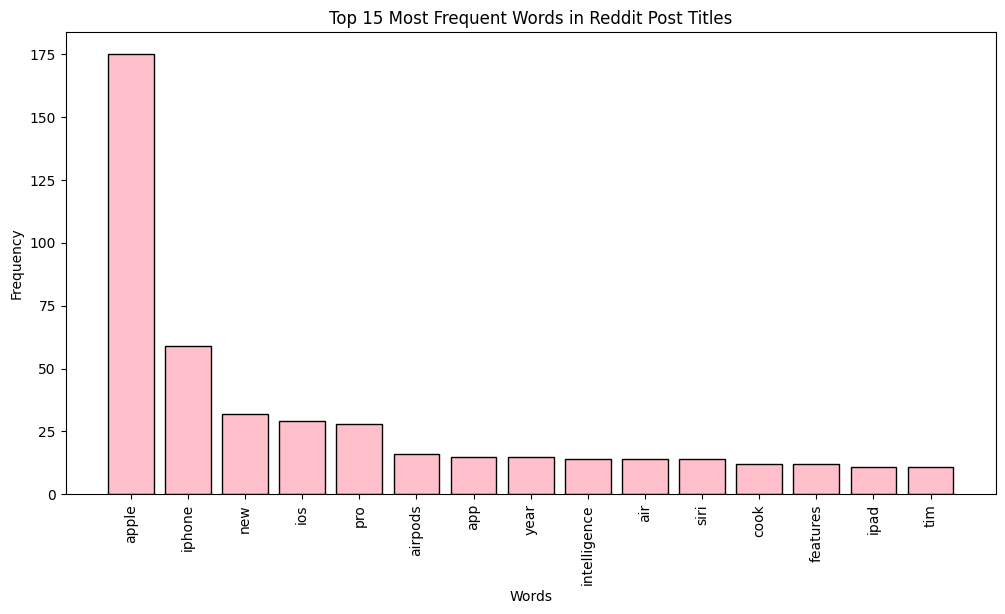

In [28]:
#  Base English stopwords (Ex. I, You, Is)
stop_words = set(stopwords.words('english'))

#  Add custom unwanted words 
custom_stopwords = {
    'says','reddit'
    }

# Merge them together
stop_words.update(custom_stopwords)

# Clean and extract words from titles 
title_clean = top_reddit_posts['Title'].astype(str).str.lower()

words = [] 

for t in title_clean:
    tokens = re.findall(r'\b[a-zA-Z]{3,}\b', t)
    tokens = [w for w in tokens if w not in stop_words]
    for w in set(tokens):   # unique per title
        words.append(w)

# Count word frequency
word_counts = Counter(words)

# Top 15 most frequent words
top_words = word_counts.most_common(15)


# Plot
plt.figure(figsize=(12, 6))
labels, counts = zip(*top_words)
plt.bar(labels, counts, 
        color= 'pink',
        edgecolor= 'black')
plt.xticks(rotation=90)
plt.title('Top 15 Most Frequent Words in Reddit Post Titles')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.show()

### 3.3.2 Frequent Bigram Word (2-Word Combos)

In [29]:
from nltk.util import ngrams

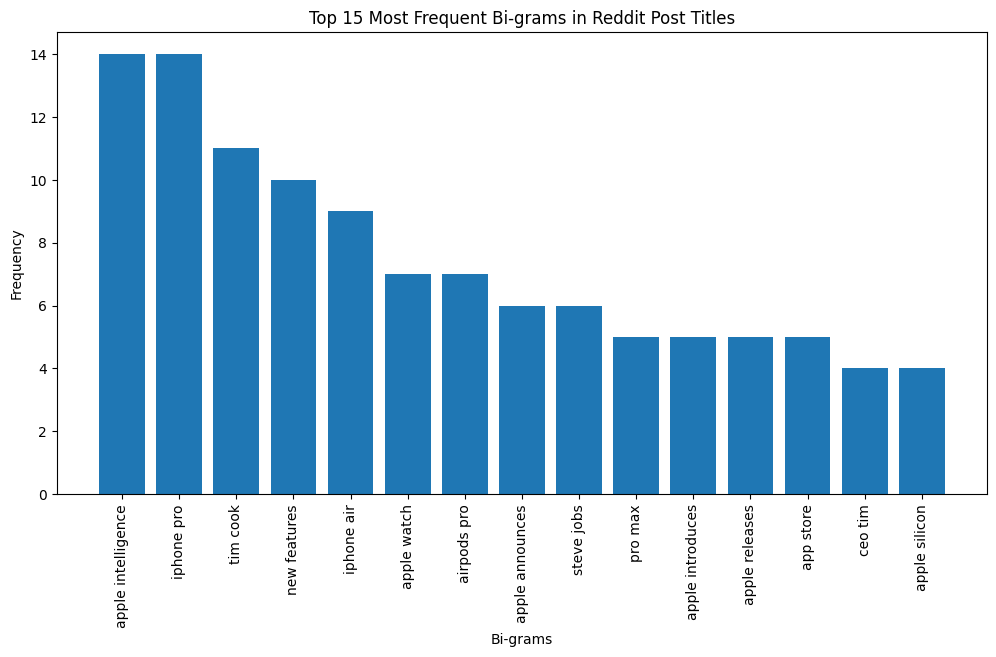

In [30]:
bigram_list = []

for t in title_clean:
    tokens = re.findall(r'\b[a-zA-Z]{3,}\b', t)
    tokens = [w for w in tokens if w not in stop_words]
    bigrams_in_title = set(ngrams(tokens, 2))
    
    for bg in bigrams_in_title:
        bigram_list.append(bg)

# Count bi-gram frequency
bigram_counts = Counter(bigram_list)

# Top 15 bi-grams
top_bigrams = bigram_counts.most_common(15)

# Prepare labels
labels, counts = zip(*top_bigrams)
labels = [' '.join(bg) for bg in labels]  # ('apple','watch') -> 'apple watch'

# Plot
plt.figure(figsize=(12, 6))
plt.bar(labels, counts)
plt.xticks(rotation=90)
plt.title('Top 15 Most Frequent Bi-grams in Reddit Post Titles')
plt.xlabel('Bi-grams')
plt.ylabel('Frequency')
plt.show()

### 3.3.3 Average Title Length Per Flair

In [31]:
top_reddit_posts['Title_Word_Count'].describe()

count    250.000000
mean      12.172000
std        5.656714
min        2.000000
25%        9.000000
50%       11.000000
75%       13.000000
max       50.000000
Name: Title_Word_Count, dtype: float64

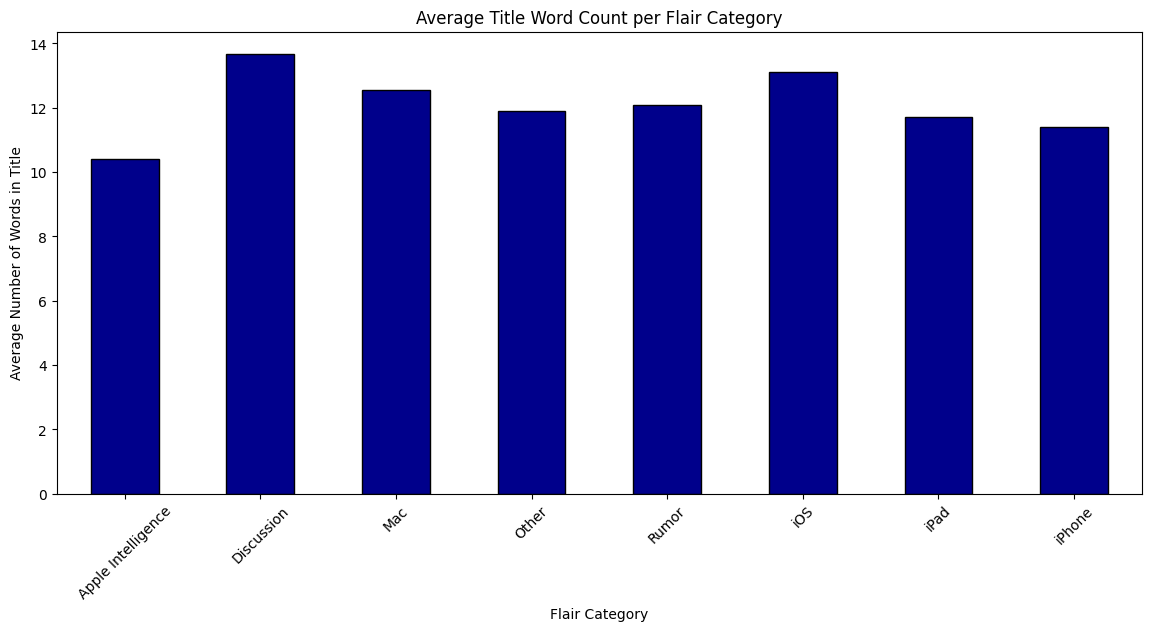

In [32]:
avg_title_length = top_reddit_posts.groupby('Flair_Clean')['Title_Word_Count'].mean()

plt.figure(figsize=(14,6))
avg_title_length.plot(kind='bar', color='darkblue', edgecolor='black')

plt.title('Average Title Word Count per Flair Category')
plt.xlabel('Flair Category')
plt.ylabel('Average Number of Words in Title')
plt.xticks(rotation=45)
plt.show()

## 3.4 Sentimental Analysis 

### 3.4.1 Sentimental Analysis Distribution

In [33]:
top_reddit_posts['Title_Sent'].value_counts()

Title_Sent
Neutral     125
Positive     71
Negative     54
Name: count, dtype: int64

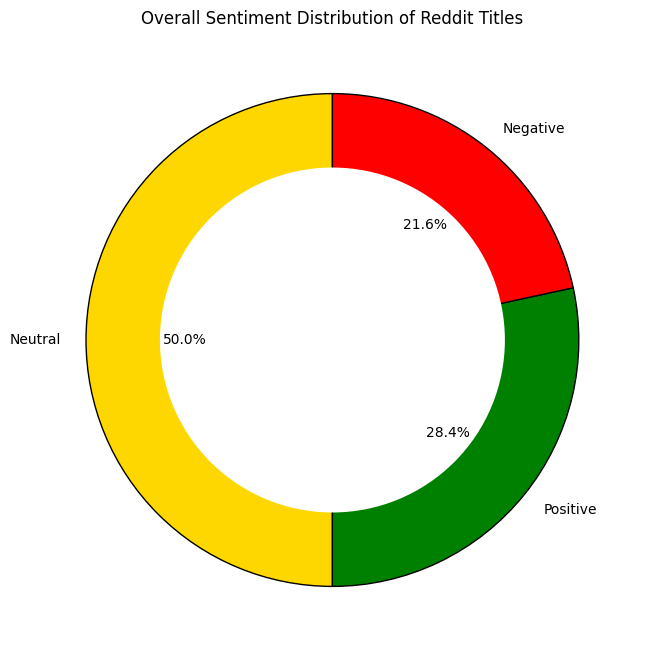

In [34]:
sentiment_counts = top_reddit_posts['Title_Sent'].value_counts()

# Colors (match your other charts)
colors = ['gold', 'green', 'red']  

plt.figure(figsize=(8,8))

# Pie chart
plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    wedgeprops={'edgecolor': 'black'}
)
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Overall Sentiment Distribution of Reddit Titles')
plt.show()

### 3.4.2 Relationship Between **Flair** and **Sentiment Analysis**

In [35]:
flair_sent = top_reddit_posts[top_reddit_posts['Flair'] != 'None']

# Group by Flair and Title_Sent and count posts
sentiment_flair_counts = (
    flair_sent
    .groupby(['Flair_Clean', 'Title_Sent'])
    .size()                       
    .unstack(fill_value=0)        
    .sort_index()                 
)

sentiment_flair_counts

Title_Sent,Negative,Neutral,Positive
Flair_Clean,,,
Apple Intelligence,9,3,10
Discussion,10,31,9
Mac,5,5,3
Other,9,32,24
Rumor,2,14,4
iOS,4,9,5
iPad,1,4,2
iPhone,13,21,10


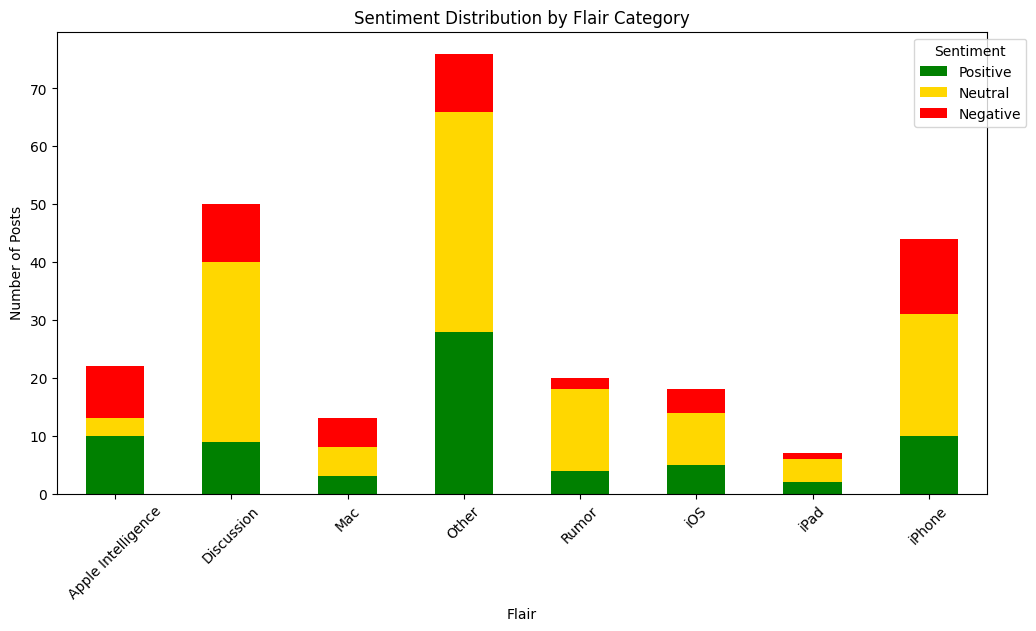

In [36]:
sentiment_by_flair = top_reddit_posts.groupby(
    ['Flair_Clean', 'Title_Sent']
).size().unstack(fill_value=0)

# Make sure columns appear in a fixed order
sentiment_by_flair = sentiment_by_flair[['Positive', 'Neutral', 'Negative']]

# Colors for each sentiment
sentiment_colors = {
    'Positive': 'green',
    'Neutral': 'gold',
    'Negative': 'red'
}

sentiment_by_flair.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6),
    color=[sentiment_colors[col] for col in sentiment_by_flair.columns]
)

plt.title('Sentiment Distribution by Flair Category')
plt.xlabel('Flair')
plt.ylabel('Number of Posts')
plt.xticks(rotation=45)
plt.legend(title='Sentiment', bbox_to_anchor=(1.05, 1))
plt.show()

### 3.4.3 Relationship Between **Frequent Words** and **Sentiment Analysis**

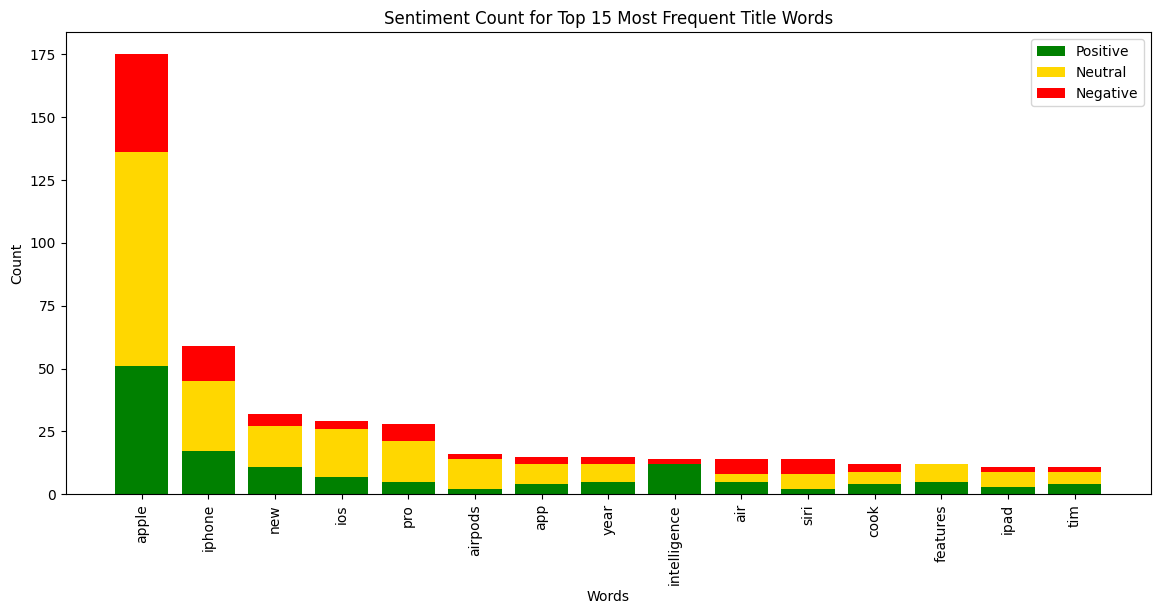

In [37]:
word_to_titles = {}  

for idx, t in enumerate(title_clean):
    unique_words = set(re.findall(r'\b[a-zA-Z]{3,}\b', t))
    for w in unique_words:
        if w not in stop_words:
            word_to_titles.setdefault(w, []).append(idx)


# Sentiment counting 
sentiment_counts = {w[0]: {'Positive': 0, 'Negative': 0, 'Neutral': 0} 
                    for w in top_words}

for word_tuple in top_words:
    word = word_tuple[0]
    rows = word_to_titles[word]  
    for r in rows:
        sent = top_reddit_posts.loc[r, 'Title_Sent']
        sentiment_counts[word][sent] += 1


# Prepare plot data 
labels = [w[0] for w in top_words]
positive = [sentiment_counts[w]['Positive'] for w in labels]
negative = [sentiment_counts[w]['Negative'] for w in labels]
neutral  = [sentiment_counts[w]['Neutral']  for w in labels]


# Plot 
plt.figure(figsize=(14,6))

plt.bar(labels, positive, label='Positive', color='green')
plt.bar(labels, neutral,  bottom=positive, label='Neutral', color='gold')
plt.bar(labels, negative, bottom=[positive[i] + neutral[i] for i in range(len(labels))], 
        label='Negative', color='red')

plt.xticks(rotation=90)
plt.title('Sentiment Count for Top 15 Most Frequent Title Words')
plt.xlabel('Words')
plt.ylabel('Count')
plt.legend()
plt.show()

### 3.4.4 Relationship Between **Frequent Bigram** and **Sentiment Analysis**

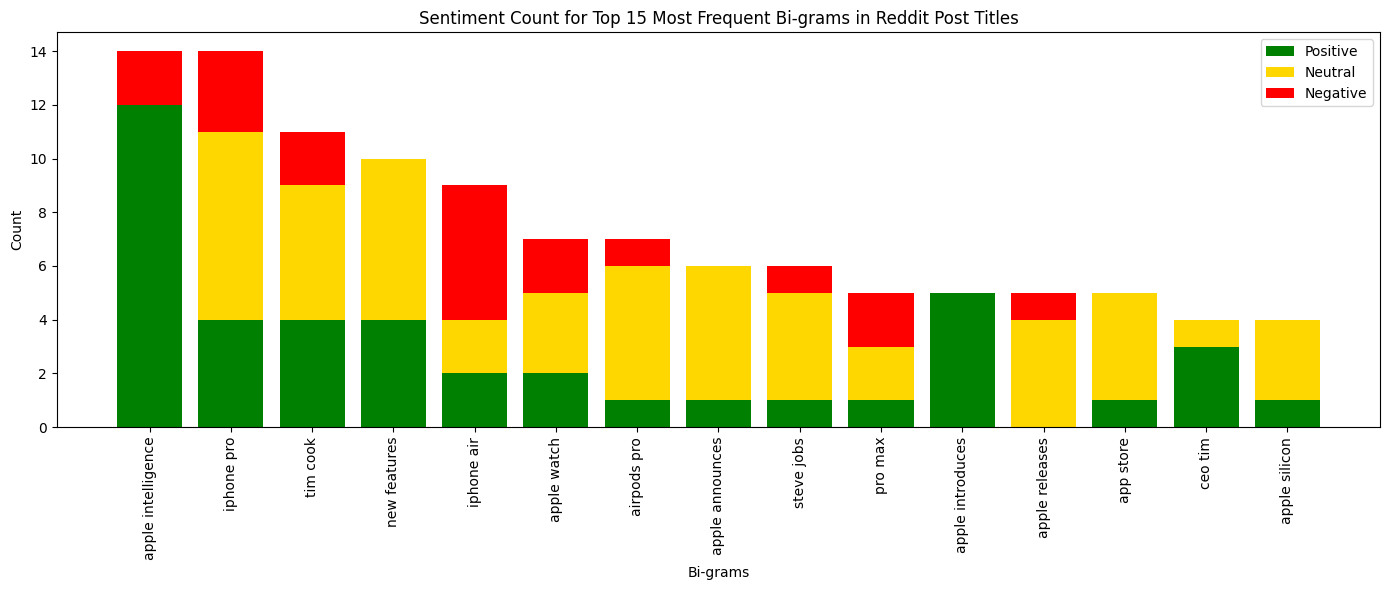

In [38]:
bigram_to_titles = {}
bigram_list = []

for idx, t in enumerate(title_clean):
    tokens = re.findall(r'\b[a-zA-Z]{3,}\b', t)
    tokens = [w for w in tokens if w not in stop_words]

    # unique bigrams per title
    bigrams_in_title = set(ngrams(tokens, 2))

    for bg in bigrams_in_title:
        bigram_list.append(bg)
        bigram_to_titles.setdefault(bg, []).append(idx)

bigram_counts = Counter(bigram_list)

top_bigrams = bigram_counts.most_common(15)

# Convert bigrams to readable text labels
bg_labels = [' '.join(bg) for bg, _ in top_bigrams]

sentiment_counts_bg = {label: {'Positive': 0, 'Negative': 0, 'Neutral': 0}
                       for label in bg_labels}

for bg, _ in top_bigrams:
    label = ' '.join(bg)
    rows = bigram_to_titles[bg]

    for r in rows:
        sent = top_reddit_posts.loc[r, 'Title_Sent']
        sentiment_counts_bg[label][sent] += 1

positive = [sentiment_counts_bg[w]['Positive'] for w in bg_labels]
neutral  = [sentiment_counts_bg[w]['Neutral']  for w in bg_labels]
negative = [sentiment_counts_bg[w]['Negative'] for w in bg_labels]


plt.figure(figsize=(14,6))

plt.bar(bg_labels, positive, label='Positive', color='green')
plt.bar(bg_labels, neutral,  bottom=positive, label='Neutral', color='gold')
plt.bar(bg_labels,
        negative,
        bottom=[positive[i] + neutral[i] for i in range(len(bg_labels))],
        label='Negative',
        color='red')

plt.xticks(rotation=90)
plt.title('Sentiment Count for Top 15 Most Frequent Bi-grams in Reddit Post Titles')
plt.xlabel('Bi-grams')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

### 3.4.5 Relationship Between **Upvotes** and **Sentimental Analysis**

In [39]:
sentiment_upvotes = top_reddit_posts.groupby('Title_Sent')['Upvotes'].agg(
    Count='count',
    Mean_Upvotes='mean',
    Median_Upvotes='median',
    Max_Upvotes='max'
)

print(sentiment_upvotes)

            Count  Mean_Upvotes  Median_Upvotes  Max_Upvotes
Title_Sent                                                  
Negative       54   2591.814815          2098.0         9869
Neutral       125   2443.336000          2052.0        13574
Positive       71   2801.591549          2070.0        11265


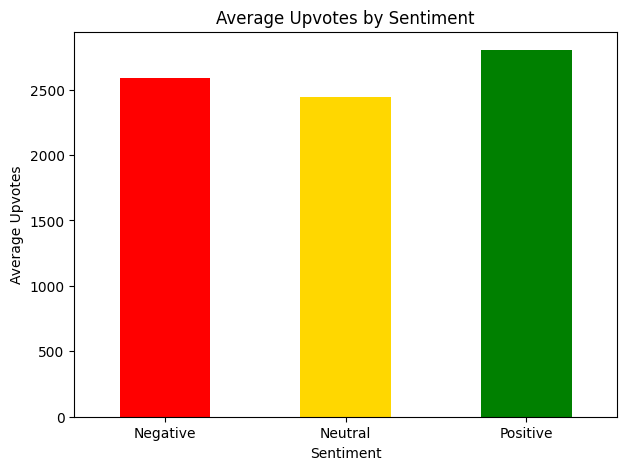

In [40]:
mean_upvotes = top_reddit_posts.groupby('Title_Sent')['Upvotes'].mean()

plt.figure(figsize=(7,5))
mean_upvotes.plot(kind='bar', color=['red','gold','green'])

plt.title('Average Upvotes by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Average Upvotes')
plt.xticks(rotation=0)
plt.show()

## 3.5 Time-Series (UTC)

In [41]:
top_reddit_posts['Hour_Post'] = top_reddit_posts['Created_At'].dt.hour
top_reddit_posts['Day_of_Week'] = top_reddit_posts['Created_At'].dt.day_name()


In [42]:
# old_order ['Title', 'Upvotes', 'Flair', 'Flair_Clean', 'Num_Comments', 'Body', 'Created_UTC',
#        'Post_ID', 'Created_At', 'Created_Date', 'Created_Time',
#        'Title_compound', 'Title_Sent', 'Title_Word_Count', 'Body_Word_Count',
#        'Log_Upvotes', 'Log_Num_Comments', 'Log_Body_Word_Count', 'Flair_Clean',
#        'Hour_Post', 'Day_of_Week']

new_order = ['Title', 'Upvotes', 'Log_Upvotes', 'Flair', 'Flair_Clean' ,
      'Num_Comments', 'Log_Num_Comments', 'Body', 'Created_UTC',
      'Post_ID', 'Created_At', 'Created_Date', 'Day_of_Week', 'Created_Time', 'Hour_Post',
      'Title_Word_Count', 'Body_Word_Count', 'Log_Body_Word_Count', 'Title_compound', 'Title_Sent'
        ]

top_reddit_posts = top_reddit_posts[new_order]

### 3.5.1 Post Per Hour of the Day

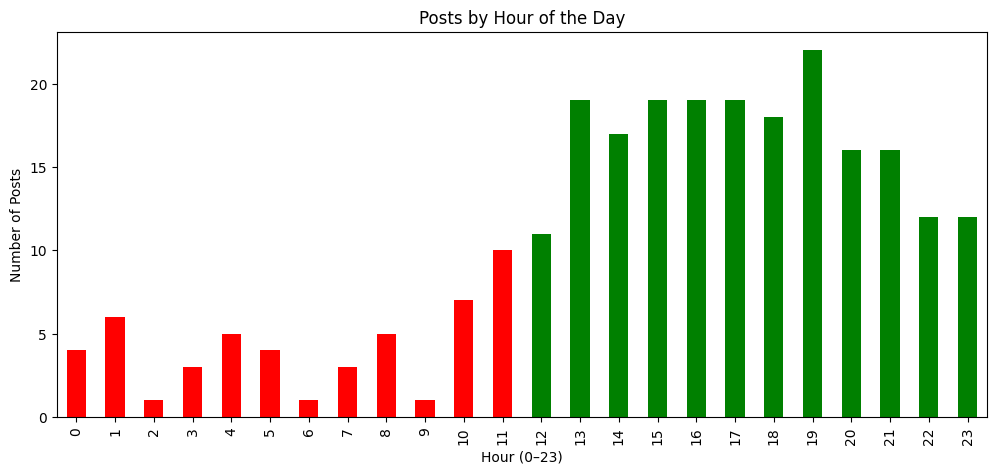

In [43]:
Posts_Per_Hour = top_reddit_posts['Hour_Post'].value_counts().sort_index()

# Choose color per hour: green for 12-23, red for 0-11
Colors_Hour = [
    'green' if h >= 12 
    else 'red' for h in Posts_Per_Hour.index
]

plt.figure(figsize=(12,5))
Posts_Per_Hour.plot(kind='bar', color= Colors_Hour)
plt.title('Posts by Hour of the Day')
plt.xlabel('Hour (0–23)') #12 AM - 11 PM
plt.ylabel('Number of Posts')
plt.show()

### 3.5.2 Post by Day of the Week

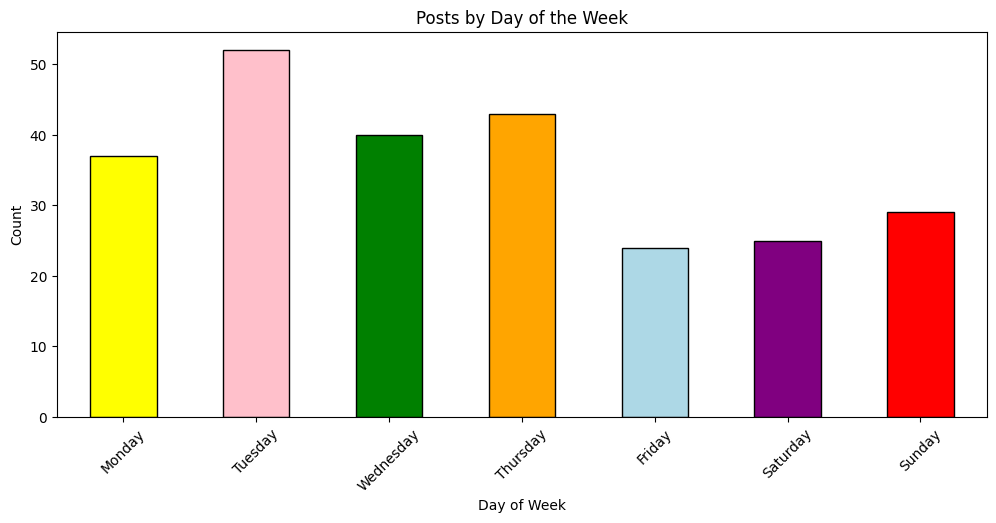

In [44]:
Posts_Per_Day_of_Week = top_reddit_posts['Day_of_Week'].value_counts().loc[
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
]

# Create color mapping for Day_of_Weeks
colors_Day_of_Week = ['yellow', 'pink', 'green', 'orange', 'lightblue', 'purple', 'red']

plt.figure(figsize=(12, 5))
Posts_Per_Day_of_Week.plot(kind='bar', color=colors_Day_of_Week, edgecolor='black')

plt.title('Posts by Day of the Week')
plt.xlabel('Day of Week')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

### 3.5.3 Post over Year

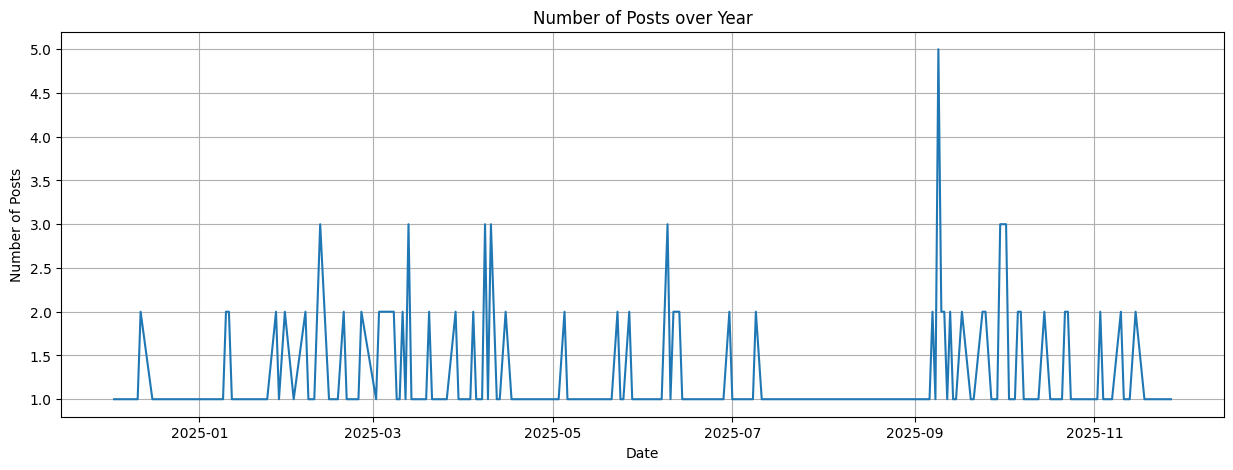

In [45]:
Posts_Per_Day = top_reddit_posts.groupby('Created_Date').size()

plt.figure(figsize=(15,5))
Posts_Per_Day.plot(kind='line')
plt.title('Number of Posts over Year')
plt.xlabel('Date')
plt.ylabel('Number of Posts')
plt.grid(True)
plt.show()

### 3.5.4 Monthly Post by Flair Trend

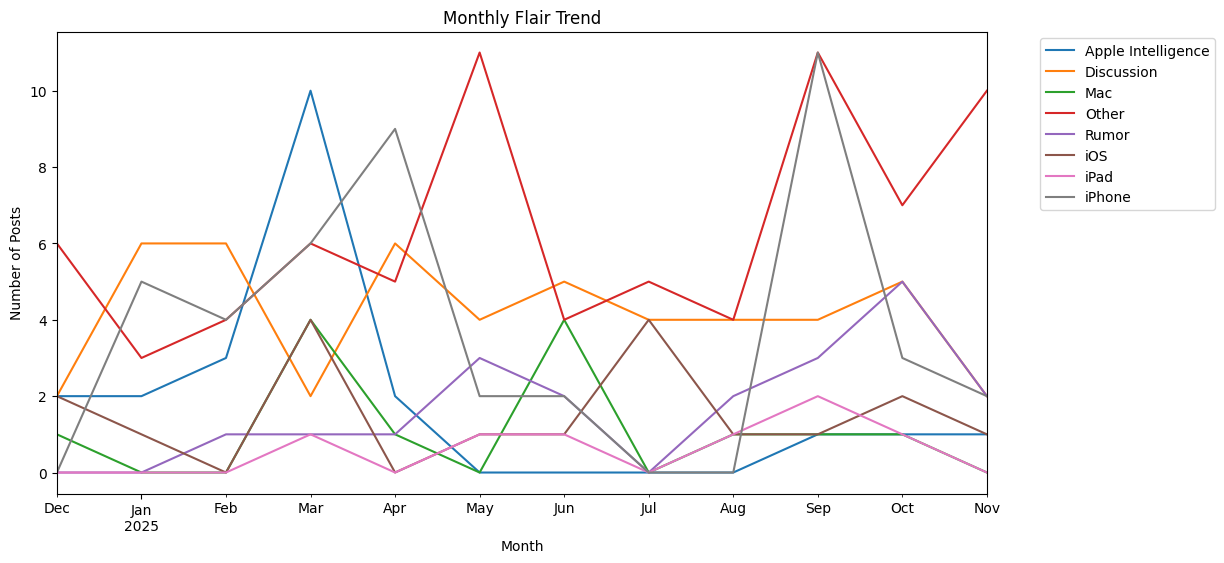

In [46]:
top_reddit_posts['Month'] = top_reddit_posts['Created_At'].dt.to_period('M').dt.to_timestamp()

Weekly_Trend = top_reddit_posts.groupby(['Month', 'Flair_Clean']).size().unstack(fill_value=0)

Weekly_Trend.plot(figsize=(12,6))
plt.title('Monthly Flair Trend')
plt.xlabel('Month')
plt.ylabel('Number of Posts')
plt.legend(bbox_to_anchor=(1.05,1))
plt.show()

### 3.5.5 Upvotes over Year

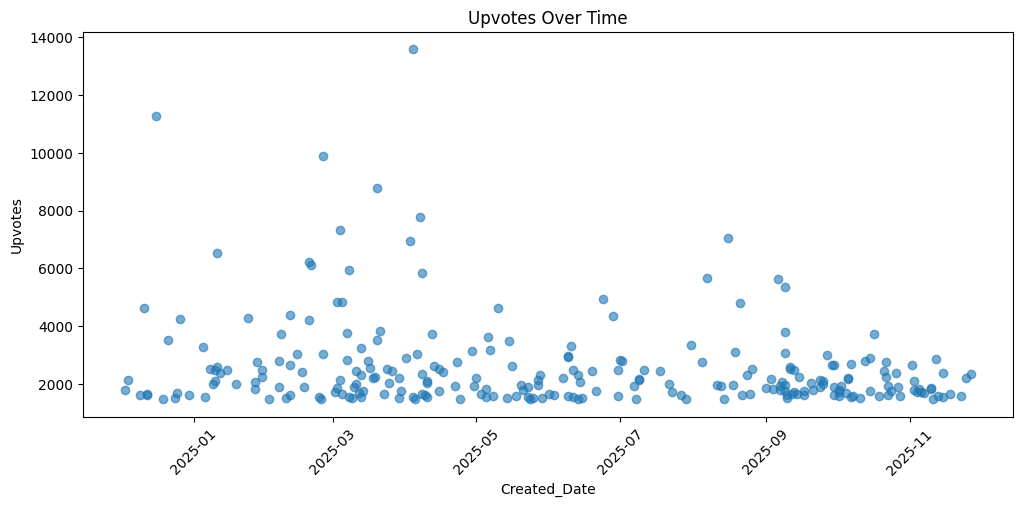

In [47]:
plt.figure(figsize=(12,5))
plt.scatter(
    top_reddit_posts['Created_Date'], 
    top_reddit_posts['Upvotes'], 
    alpha=0.6
)
plt.title('Upvotes Over Time')
plt.xlabel('Created_Date')
plt.ylabel('Upvotes')
plt.xticks(rotation=45)
plt.show()

### 3.5.6 Average Sentimental over Year

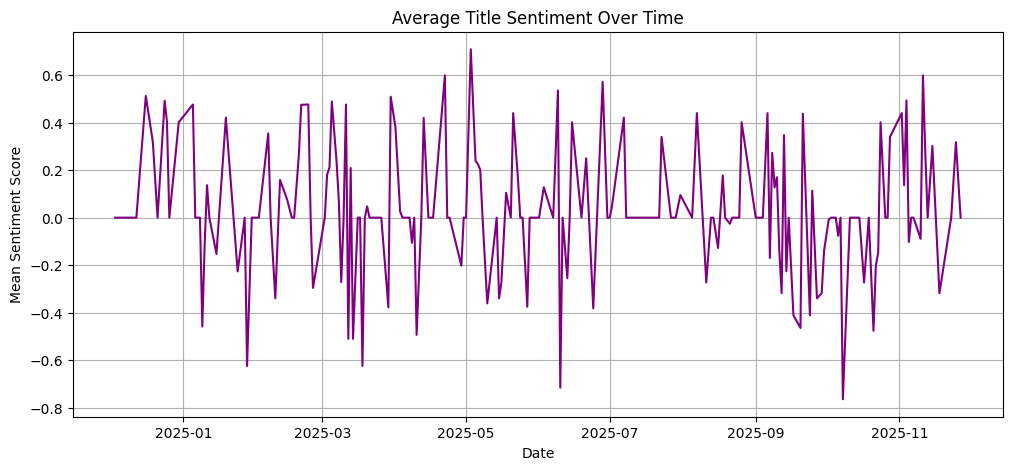

In [48]:
Sentiment_Over_Time = top_reddit_posts.groupby('Created_Date')['Title_compound'].mean()

plt.figure(figsize=(12,5))
Sentiment_Over_Time.plot(kind='line', color='purple')
plt.title('Average Title Sentiment Over Time')
plt.xlabel('Date')
plt.ylabel('Mean Sentiment Score')
plt.grid(True)
plt.show()

# Step 4 : Ask a question about your data 

## **4.1 Does the mood tone of a Reddit post (from Sentimental Analysis) influence to the engagement (Upvotes & Comments)?**

In [49]:
import seaborn as sea

### 4.1.1 Do positive posts receive more upvotes than negative or neutral mood posts? 

In [50]:
group_means = top_reddit_posts.groupby("Title_Sent")[["Upvotes"]].mean()
print(group_means)

                Upvotes
Title_Sent             
Negative    2591.814815
Neutral     2443.336000
Positive    2801.591549


/var/folders/rk/vrfbphk975xfx3m0npm7jyww0000gn/T/ipykernel_12394/2492363862.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sea.boxplot(data= top_reddit_posts, x="Title_Sent", y="Upvotes", palette=["green","gold","red"])


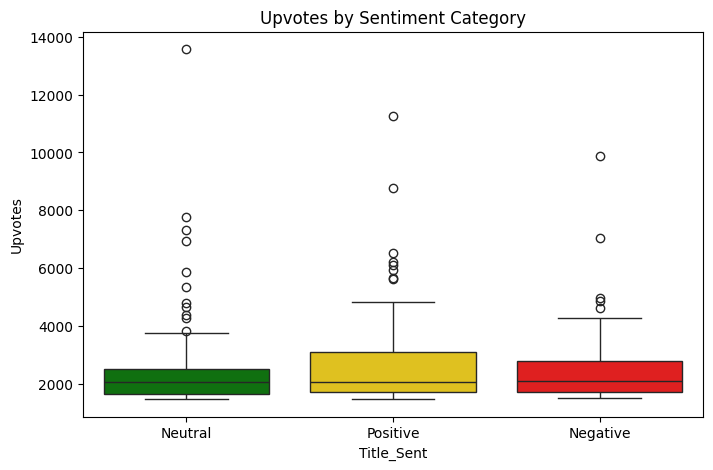

In [51]:
plt.figure(figsize=(8,5))
sea.boxplot(data= top_reddit_posts, x="Title_Sent", y="Upvotes", palette=["green","gold","red"])
plt.title("Upvotes by Sentiment Category")
plt.show()

Test for difference in means between each group whether engagement (Upvotes/Comments) differed across sentiment categories (Positive, Nuetral, Negative) by using **Kruskai-Wallis**. 

**Kruskai-Wallis** is non-parametric test due to the engagement variables were highly skewed with outliers, which is violates the ANOVA assumption (that need to be normal distrbution)

**Hypthesis Testing**
Null hypothesis (H0) is that population means are equal  
Alteranative hypothesis (H1) is that population mean are differ

In [52]:
from scipy.stats import kruskal

In [53]:
pos_upvotes = top_reddit_posts[top_reddit_posts['Title_Sent'] == 'Positive']['Upvotes']
neu_upvotes   = top_reddit_posts[top_reddit_posts['Title_Sent'] == 'Neutral']['Upvotes']
neg_upvotes  = top_reddit_posts[top_reddit_posts['Title_Sent'] == 'Negative']['Upvotes']

h_stat, p = kruskal(pos_upvotes, neu_upvotes, neg_upvotes)


print("p-value =", p)

if p <= 0.05: 
    print("Reject the null hypothesis: There is a significant between groups")
else:  
    print("Fail to reject null hypthesis: " \
    "There is NO statistically significant different between the groups")




p-value = 0.44503257762007253
Fail to reject null hypthesis: There is NO statistically significant different between the groups


### 4.1.2 Does sentiment affect how many comments a post receives?

In [54]:
num_comments_means = top_reddit_posts.groupby("Title_Sent")[["Num_Comments" ]].mean()
print(num_comments_means)

            Num_Comments
Title_Sent              
Negative      440.500000
Neutral       432.760000
Positive      576.098592


/var/folders/rk/vrfbphk975xfx3m0npm7jyww0000gn/T/ipykernel_12394/3590035566.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sea.boxplot(data=top_reddit_posts, x="Title_Sent", y="Num_Comments", palette=["green","gold","red"])


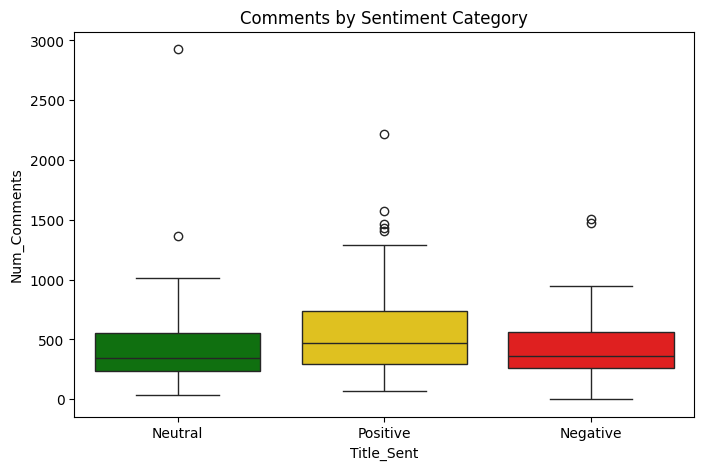

In [55]:
plt.figure(figsize=(8,5))
sea.boxplot(data=top_reddit_posts, x="Title_Sent", y="Num_Comments", palette=["green","gold","red"])
plt.title("Comments by Sentiment Category")
plt.show()

In [56]:
pos_comments = top_reddit_posts[top_reddit_posts["Title_Sent"] == "Positive"]["Num_Comments"]
neu_comments = top_reddit_posts[top_reddit_posts["Title_Sent"] == "Neutral"]["Num_Comments"]
neg_comments = top_reddit_posts[top_reddit_posts["Title_Sent"] == "Negative"]["Num_Comments"]

h_stat, p = kruskal(pos_comments, neu_comments, neg_comments)


print("p-value =", p)

if p <= 0.05: 
    print("Reject the null hypothesis: There is a significant between groups")
else:  
    print("Fail to reject null hypthesis: " \
    "There is NO statistically significant different between the groups")



p-value = 0.02352834308103899
Reject the null hypothesis: There is a significant between groups


### 4.1.3 Is compound sentiment correlated with engagement?

Measure Correlation by using **Spearman** correlation cofficients as each method captures a different type of relationship.  Spearman correlation is a non-parametric test that does not require normality and is more suitable to skewed data and outliers which are present in Number of Comments and Upvotes Distribution. In short, **Spearman** measures whether higher sentiment scores tend to be associated with higher engagment or not (Upvotes and Number of Comments)

Due to the upvotes and number of comments that are extremely skewed, using **Log_Transformation** (from 2.2.2) make it stabilise variance and make data suitable for correlation analysis. 

In [57]:
from scipy.stats import spearmanr

In [58]:
corr_up, p_up = spearmanr(top_reddit_posts['Title_compound'], top_reddit_posts['Log_Upvotes']) # corr_up --> Spearman correlation coefficiant, p_up --> p-value 
corr_com, p_com = spearmanr(top_reddit_posts['Title_compound'], top_reddit_posts['Log_Num_Comments'])
print("Sentiment vs Upvotes:", corr_up, p_up)
print("Sentiment vs Comments:", corr_com, p_com)

Sentiment vs Upvotes: 0.018998481192539343 0.7650057279364539
Sentiment vs Comments: 0.1375074706632037 0.029733415117586346


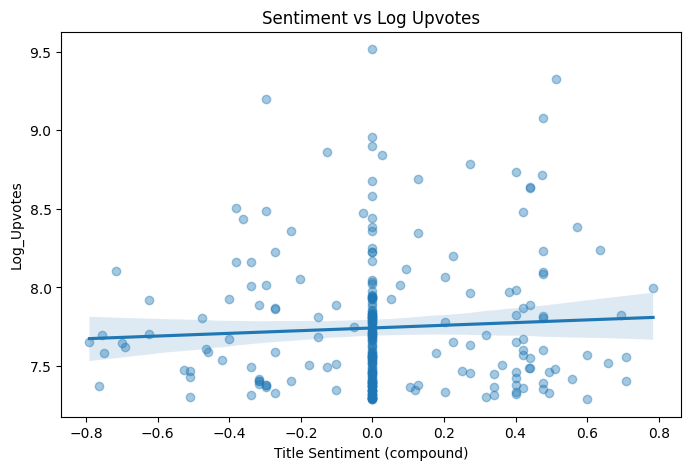

In [59]:
plt.figure(figsize=(8,5))
sea.regplot(x='Title_compound', y='Log_Upvotes', data=top_reddit_posts,
            scatter_kws={'alpha':0.4})
plt.title("Sentiment vs Log Upvotes")
plt.xlabel("Title Sentiment (compound)")
plt.ylabel("Log_Upvotes")
plt.show()


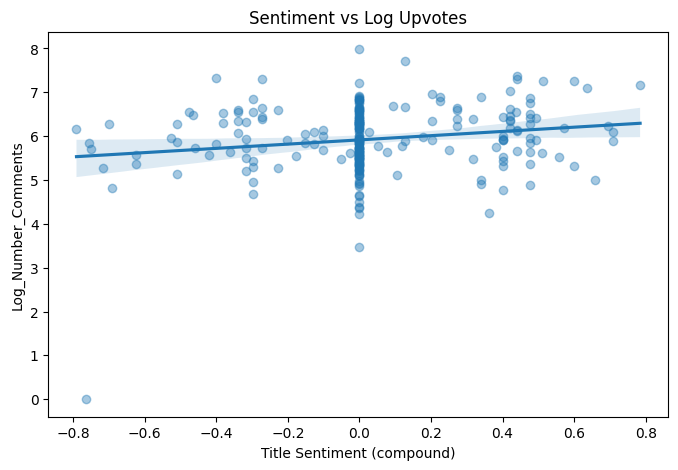

In [60]:
plt.figure(figsize=(8,5))
sea.regplot(x='Title_compound', y='Log_Num_Comments', data=top_reddit_posts,
            scatter_kws={'alpha':0.4})
plt.title("Sentiment vs Log Upvotes")
plt.xlabel("Title Sentiment (compound)")
plt.ylabel("Log_Number_Comments")
plt.show()


### 4.1.4 Does sentiment remain significant afteer controlling for other factors?

In [61]:
top_reddit_posts['Log_Upvotes'] = np.log1p(top_reddit_posts['Upvotes'])

In [62]:
%pip install statsmodels


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [63]:
import statsmodels.api as sm
import pandas as pd

df = top_reddit_posts.copy()

# Select features
X = df[['Title_compound', 'Title_Word_Count', 'Log_Num_Comments']]
X = sm.add_constant(X)

y = df['Log_Upvotes']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            Log_Upvotes   R-squared:                       0.148
Model:                            OLS   Adj. R-squared:                  0.138
Method:                 Least Squares   F-statistic:                     14.27
Date:                Tue, 02 Dec 2025   Prob (F-statistic):           1.33e-08
Time:                        05:54:13   Log-Likelihood:                -118.47
No. Observations:                 250   AIC:                             244.9
Df Residuals:                     246   BIC:                             259.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                6.3877      0.212  